  PRÉDICTION DU RISQUE D'ABSENTÉISME - HR ANALYTICS

📊 Dataset chargé : 740 lignes, 21 colonnes
   Colonnes : ['ID', 'Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Transportation expense', 'Distance from Residence to Work', 'Service time', 'Age', 'Hit target', 'Justification Delay', 'Education', 'Son', 'Social smoker', 'Pet', 'Weight', 'Height', 'Body mass index', 'Absenteeism time in hours', 'Year', 'Day_of_month']

  ÉTAPE 1 : NETTOYAGE DES DONNÉES
   ✅ Suppression des mois <= 0 : 3 lignes supprimées
   ✅ Suppression des doublons : 0 lignes supprimées
   ✅ Suppression du faux profil (ID 29) : 1 lignes supprimées
   ✅ Filtrage incohérences disciplinaires : 11 lignes supprimées
   ✅ Saisons mises en conformité avec Power Query

  MODÈLE : PRÉDICTION DU DÉLAI AVANT LA PROCHAINE ABSENCE

   🔄 Génération des colonnes temporelles spécifiques au Modèle 2...
   🔄 Calcul de Days_Until_Next_Absence par employé...
   ✅ 625 lignes disponibles pour l'entraînement
   📊 Da

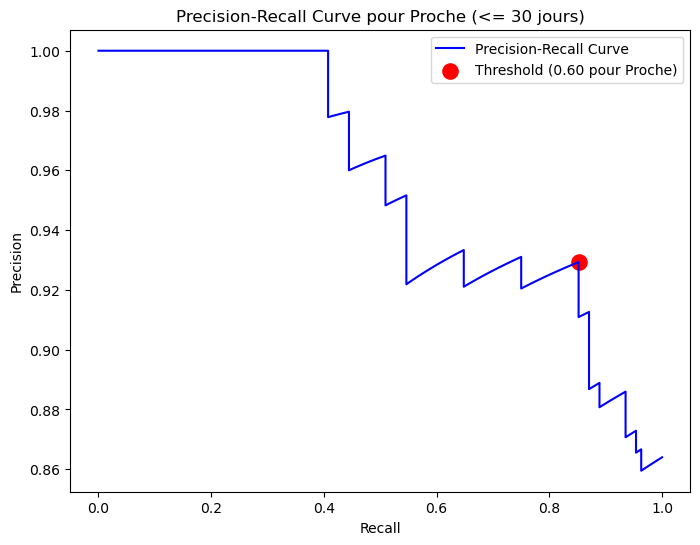

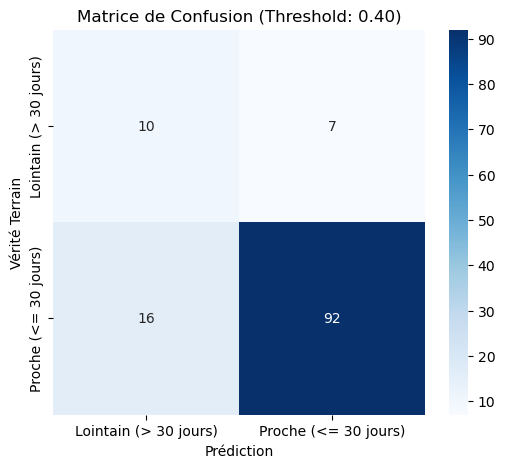


------------------------------------------------------------
   TOUTES LES FEATURES (PROXIMITÉ - Extrait de RF)
------------------------------------------------------------
   ✅ Liste complète des features sauvegardée dans : C:\Users\Malek\Downloads\models\toutes_les_features_importance.csv
                            Absence_Count  0.1336  ██████
                 Days_Since_First_Absence  0.1087  █████
                         Prev_Absence_Gap  0.0933  ████
                     Absence_Last_30_Days  0.0892  ████
                   Transportation expense  0.0678  ███
                               Hit target  0.0649  ███
                          Body mass index  0.0628  ███
                                      Age  0.0626  ███
          Distance from Residence to Work  0.0509  ██
                             Service time  0.0474  ██
                        Day of the week_4  0.0208  █
                        Day of the week_3  0.0176  
                        Day of the week_2  0.01

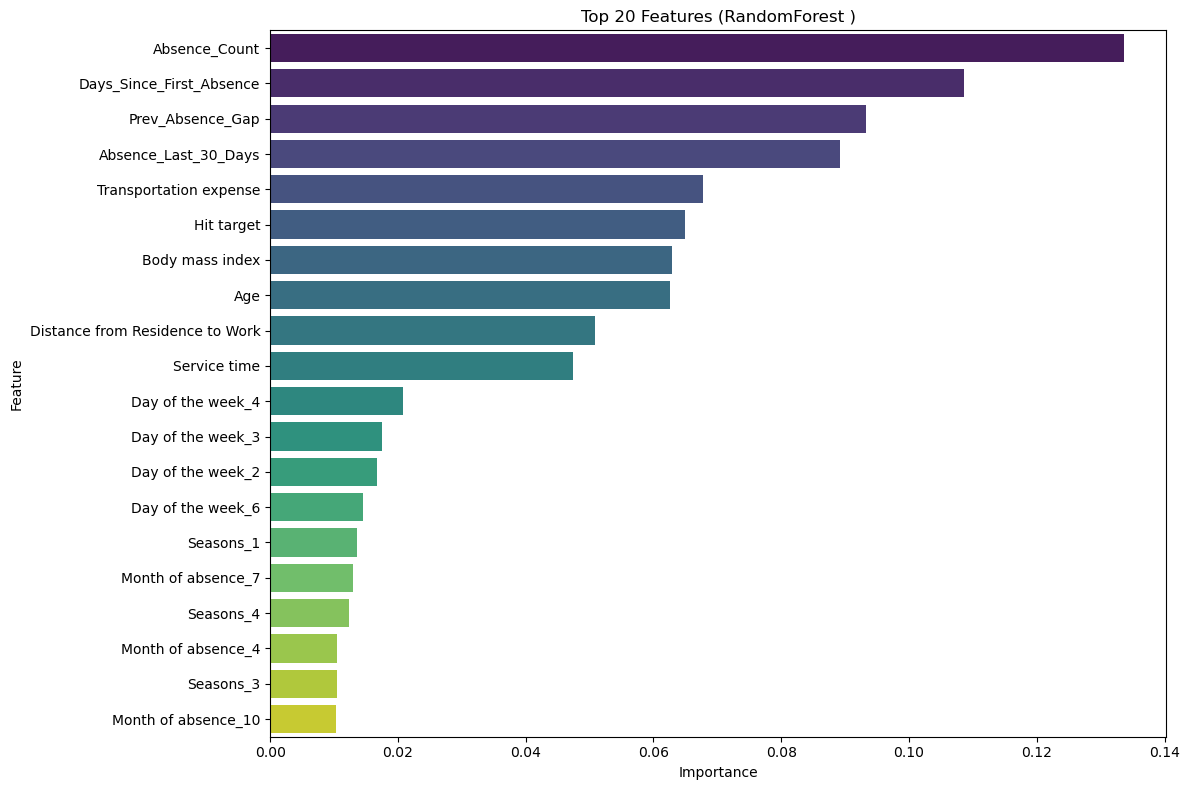

   ✅ Graphiques sauvegardés dans 'C:\Users\Malek\Downloads\models'
   ✅ Modèle 2 (Proximité) sauvegardé dans 'C:\Users\Malek\Downloads\models'
   ✅ Threshold optimal (0.40) sauvegardé dans 'proximity_threshold.pkl'

  🚀 MODÈLE PRÊT POUR LE DÉPLOIEMENT FLASK !
     1. Classification → Proximité de la prochaine absence (Jours)


In [10]:
"""
=============================================================================
 Prédiction du Risque d'Absentéisme - HR Analytics
 Projet PFE : Plateforme Intelligente de Gestion RH & Analytics
=============================================================================
 Ce script entraîne le modèle de prédiction "Time-to-Event" (Proximité) :
   - Prédit si la prochaine absence d'un employé est proche (<= 30 jours) 
     ou lointaine (> 30 jours).
=============================================================================
"""

import pandas as pd
import numpy as np
import calendar
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, KFold
)
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    StackingClassifier, HistGradientBoostingClassifier,
    ExtraTreesClassifier,
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LogisticRegression, Ridge
# Importations de XGBoost et CatBoost retirées pour éviter les erreurs d'environnement
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from collections import Counter
import warnings
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ============================================================================
# 1. CHARGEMENT DES DONNÉES
# ============================================================================
print("=" * 70)
print("  PRÉDICTION DU RISQUE D'ABSENTÉISME - HR ANALYTICS")
print("=" * 70)

df = pd.read_csv(r"C:\Users\Malek\Desktop\PFE-Integration\dados_tunisie.csv", sep=';')

print(f"\n📊 Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"   Colonnes : {list(df.columns)}")

# ============================================================================
# 2. NETTOYAGE DES DONNÉES (Même logique que Power Query)
# ============================================================================
print("\n" + "=" * 70)
print("  ÉTAPE 1 : NETTOYAGE DES DONNÉES")
print("=" * 70)

# 2.1 - Suppression des mois invalides
rows_before = len(df)
df = df[df['Month of absence'] > 0].copy()
print(f"   ✅ Suppression des mois <= 0 : {rows_before - len(df)} lignes supprimées")

# 2.2 - Suppression des doublons exacts
rows_before = len(df)
df = df.drop_duplicates()
print(f"   ✅ Suppression des doublons : {rows_before - len(df)} lignes supprimées")

# 2.3 - Suppression du faux profil employe 29 (Baccalaureat, Age=28)
rows_before = len(df)
mask_fake_profile = (df['ID'] == 29) & (df['Age'] == 28) & (df['Education'] == 1)
df = df[~mask_fake_profile].copy()
print(f"   ✅ Suppression du faux profil (ID 29) : {rows_before - len(df)} lignes supprimées")

# 2.4 - Suppression des lignes incohérentes
rows_before = len(df)
mask_incoherent_1 = (df['Reason for absence'] == 1) & (df['Justification Delay'] == 1)
mask_incoherent_2 = (df['Reason for absence'] == 8) & (df['Justification Delay'] == 1)
df = df[~(mask_incoherent_1 | mask_incoherent_2)].copy()
print(f"   ✅ Filtrage incohérences disciplinaires : {rows_before - len(df)} lignes supprimées")

# 2.5 - Renommer les raisons d'absence exactement comme dans PQ
reason_mapping = {
    1: 'Conge Annuel',
    2: 'Conge Exceptionnel - Deces',
    3: 'Conge Exceptionnel - Mariage',
    4: 'Accompagnement Medical',
    7: 'Demarche Administrative / Avocat',
    8: 'Absence Injustifiee',
    9: 'Conge Maladie Ordinaire',
    10: 'Conge Maladie Longue Duree'
}
df['Absence_Reason'] = df['Reason for absence'].map(reason_mapping).fillna('Autre')


# 2.7 - CRÉATION DES SAISONS EN CONFORMITÉ AVEC POWER QUERY
def get_season(row):
    m = row['Month of absence']
    if m in [12, 1, 2]:
        return 'Winter', 1
    elif m in [3, 4, 5]:
        return 'Spring', 2
    elif m in [6, 7, 8]:
        return 'Summer', 3
    else:
        return 'Autumn', 4

season_info = df.apply(get_season, axis=1, result_type='expand')
df['Season'] = season_info[0]
df['Seasons'] = season_info[1] # Remplace l'ancien 'Seasons' par le code cohérent
print(f"   ✅ Saisons mises en conformité avec Power Query")

# ============================================================================
# 3. MODÈLE : PRÉDICTION TIME-TO-EVENT (Jours avant prochaine absence)
# ============================================================================
print(f"\n" + "=" * 70)
print("  MODÈLE : PRÉDICTION DU DÉLAI AVANT LA PROCHAINE ABSENCE")
print("=" * 70)

export_dir = r"C:\Users\Malek\Downloads\models"
os.makedirs(export_dir, exist_ok=True)

# 3.1 - Génération des colonnes temporelles spécifiques au Modèle

print("\n   🔄 Génération des colonnes temporelles spécifiques au Modèle 2...")
df_reg = df.copy()
df_reg = df_reg.sort_values(by=['ID', 'Month of absence']).reset_index(drop=True)

# Les colonnes Year et Day_of_month sont déjà dans le dataset, on recrée juste la date
df_reg['Date'] = pd.to_datetime(dict(year=df_reg['Year'], month=df_reg['Month of absence'], day=df_reg['Day_of_month']))

# Tri chronologique obligatoire pour calculer le délai avant la prochaine absence
df_reg = df_reg.sort_values(by=['ID', 'Date']).reset_index(drop=True)

# 10.2 - Calcul de Days_Until_Next_Absence par employé
print("   🔄 Calcul de Days_Until_Next_Absence par employé...")
df_reg['Next_Absence_Date'] = df_reg.groupby('ID')['Date'].shift(-1)
df_reg['Days_Until_Next_Absence'] = (
    df_reg['Next_Absence_Date'] - df_reg['Date']
).dt.days

# Supprimer les lignes sans "prochaine absence" (dernière absence de chaque employé)
df_reg = df_reg.dropna(subset=['Days_Until_Next_Absence']).copy()
df_reg['Days_Until_Next_Absence'] = df_reg['Days_Until_Next_Absence'].astype(int)

# Supprimer les outliers extrêmes (> 365 jours)
df_reg = df_reg[df_reg['Days_Until_Next_Absence'] <= 365].copy()
df_reg = df_reg[df_reg['Days_Until_Next_Absence'] >= 0].copy()

print(f"   ✅ {len(df_reg)} lignes disponibles pour l'entraînement")
print(f"   📊 Days_Until_Next_Absence — Min: {df_reg['Days_Until_Next_Absence'].min()}, "
      f"Max: {df_reg['Days_Until_Next_Absence'].max()}, "
      f"Moyenne: {df_reg['Days_Until_Next_Absence'].mean():.1f} jours")

# ==============================
# FEATURES HISTORIQUES NETTOYÉES
# ==============================
df_reg['Absence_Count'] = df_reg.groupby('ID').cumcount()

df_reg['Prev_Date'] = df_reg.groupby('ID')['Date'].shift(1)
df_reg['Prev_Absence_Gap'] = (df_reg['Date'] - df_reg['Prev_Date']).dt.days.fillna(0)

df_reg['First_Absence_Date'] = df_reg.groupby('ID')['Date'].transform('min')
df_reg['Days_Since_First_Absence'] = (df_reg['Date'] - df_reg['First_Absence_Date']).dt.days

def get_rolling_counts(df_group):
    dates = df_group['Date'].values
    counts_30 = np.zeros(len(dates))
    for i, d in enumerate(dates):
        counts_30[i] = np.sum((dates < d) & (dates >= d - np.timedelta64(30, 'D')))
    df_group['Absence_Last_30_Days'] = counts_30
    return df_group

df_reg = df_reg.groupby('ID', group_keys=False).apply(get_rolling_counts)

clean_features = [
    'Absence_Count',
    'Days_Since_First_Absence',
    'Prev_Absence_Gap',
    'Absence_Last_30_Days',
    'Hit target',
    'Age',
    'Body mass index',
    'Transportation expense',
    'Distance from Residence to Work',
    'Service time',
    'Day of the week',
    'Seasons',
    'Month of absence'
]

reg_all_features = [f for f in clean_features if f in df_reg.columns]
X_reg = df_reg[reg_all_features].copy()

# Encodage One-Hot des variables catégorielles (crucial pour éviter qu'elles ne soient traitées comme des nombres continus)
cat_cols = ['Reason for absence', 'Month of absence', 'Day of the week', 'Seasons', 'Education']
for col in cat_cols:
    if col in X_reg.columns:
        X_reg[col] = X_reg[col].astype(str)

X_reg = pd.get_dummies(X_reg, drop_first=False).astype(float)

# TRANSFORMATION EN CLASSIFICATION BINAIRE
def classify_proximity(days):
    if days <= 30:
        return 'Proche (<= 30 jours)'
    else:
        return 'Lointain (> 30 jours)'

df_reg['Proximity_Class'] = df_reg['Days_Until_Next_Absence'].apply(classify_proximity)
y_class = df_reg['Proximity_Class'].copy()

# Encodage de la cible
le_prox = LabelEncoder()
y_class_encoded = le_prox.fit_transform(y_class)

print(f"   📌 {len(reg_all_features)} features pour la classification")
print(f"   📋 Distribution de la proximité :")
for label, count in df_reg['Proximity_Class'].value_counts().items():
    print(f"      - {label:25s} : {count:4d}")

# 10.3 - Normalisation et Split
scaler_reg = RobustScaler()
X_reg_scaled = pd.DataFrame(scaler_reg.fit_transform(X_reg), columns=X_reg.columns)

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_reg_scaled, y_class_encoded, test_size=0.2, stratify=y_class_encoded, random_state=42
)
# ============================================================================
# DATA AUGMENTATION : OVERSAMPLING (RandomOverSampler)
# ============================================================================
try:
    from imblearn.over_sampling import RandomOverSampler
except ImportError:
    import subprocess
    import sys
    print("   ⚠️ Installation de imbalanced-learn en cours...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import RandomOverSampler

print(f"   📊 Avant Augmentation - Train : {len(X_class_train)} | Test : {len(X_class_test)}")

ros = RandomOverSampler(random_state=42)
X_class_train, y_class_train = ros.fit_resample(X_class_train, y_class_train)

print(f"   📊 Après Augmentation - Train : {len(X_class_train)}")
print(f"   📋 Distribution Train équilibrée :")
unique, counts = np.unique(y_class_train, return_counts=True)
for u, c in zip(unique, counts):
    class_name = le_prox.inverse_transform([u])[0]
    print(f"      - {class_name:25s} : {c:4d}")

# 10.4 - Entraînement avec Balanced Ensemble (Stacking)
# 10.4 - Entraînement et Comparaison
print(f"\n   🔍 Évaluation et Threshold Tuning pour 'Lointain'...")
print(f"   ============================================================")
lointain_idx = list(le_prox.classes_).index('Lointain (> 30 jours)')

try:
    from imblearn.ensemble import BalancedRandomForestClassifier
except ImportError:
    pass # Already installed previously

models_to_test = {
    "Balanced Random Forest": BalancedRandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=2, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=2, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=300, max_depth=5, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=500, max_depth=15, min_samples_leaf=2, class_weight='balanced', random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, max_depth=10, l2_regularization=0.1, random_state=42),
    "StackingClassifier": StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=500, max_depth=15, min_samples_leaf=2, class_weight='balanced', random_state=42)),
            ('et', ExtraTreesClassifier(n_estimators=500, max_depth=15, min_samples_leaf=2, class_weight='balanced', random_state=42)),
            ('hgb', HistGradientBoostingClassifier(max_iter=300, max_depth=10, l2_regularization=0.1, random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000)
    )
}

best_overall_f1_macro = 0
best_class_model = None
best_class_name = ""
best_threshold = 0.5
best_prec = None
best_rec = None
best_idx = 0

from sklearn.metrics import precision_recall_curve

for name, model in models_to_test.items():
    model.fit(X_class_train, y_class_train)
    y_proba = model.predict_proba(X_class_test)
    
    y_proba_l = y_proba[:, lointain_idx]
    
    # Calcul de la courbe PR pour la classe 'Proche' (car c'est la cible principale métier)
    proche_idx = 1 - lointain_idx
    y_proba_p = y_proba[:, proche_idx]
    y_test_bin_p = (y_class_test == proche_idx).astype(int)
    
    prec_tmp, rec_tmp, thresh_tmp = precision_recall_curve(y_test_bin_p, y_proba_p)
    
    print(f"\n   🔹 {name}")
    best_model_f1 = 0
    best_model_thresh = 0
    best_model_acc = 0
    best_model_f1_weighted = 0
    
    thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    for thresh in thresholds:
        pred_bin = (y_proba_l >= thresh).astype(int)
        y_pred_tmp = np.where(pred_bin == 1, lointain_idx, 1 - lointain_idx)
        
        acc = accuracy_score(y_class_test, y_pred_tmp)
        f1_macro = f1_score(y_class_test, y_pred_tmp, average='macro')
        f1_weighted = f1_score(y_class_test, y_pred_tmp, average='weighted')
        
        if f1_macro > best_model_f1:
            best_model_f1 = f1_macro
            best_model_thresh = thresh
            best_model_acc = acc
            best_model_f1_weighted = f1_weighted
            
    print(f"      Threshold optimal : {best_model_thresh:.2f}")
    print(f"      Accuracy          : {best_model_acc*100:.1f}%")
    print(f"      F1-Macro          : {best_model_f1:.4f}  ← (métrique de sélection)")
    print(f"      F1-Weighted       : {best_model_f1_weighted:.4f}\n")
    
    if best_model_f1 > best_overall_f1_macro:
        best_overall_f1_macro = best_model_f1
        best_class_model = model
        best_class_name = name
        best_threshold = best_model_thresh
        best_prec = prec_tmp
        best_rec = rec_tmp
        best_thresh_array = thresh_tmp
        if len(thresh_tmp) > 0:
            # Le threshold pour Proche correspond à (1 - threshold_lointain)
            best_idx = np.argmin(np.abs(thresh_tmp - (1 - best_model_thresh)))
        else:
            best_idx = 0

# Variables pour le graphique
prec = best_prec
rec = best_rec
thresholds_array = best_thresh_array

# Recalculer les prédictions finales avec le meilleur modèle
y_proba_best = best_class_model.predict_proba(X_class_test)[:, lointain_idx]
best_pred_bin = (y_proba_best >= best_threshold).astype(int)
best_y_pred = np.where(best_pred_bin == 1, lointain_idx, 1 - lointain_idx)

print(f"\n   🏆 Meilleur modèle sélectionné : {best_class_name} (threshold={best_threshold:.2f}, F1-Macro={best_overall_f1_macro:.4f})")

# 10.5 - Résultats finaux
print(f"\n" + "=" * 70)
print(f"  🏆 RÉSULTATS DU MEILLEUR MODÈLE PROXIMITÉ : {best_class_name}")
print("=" * 70)

acc_prox = accuracy_score(y_class_test, best_y_pred)
f1_prox = f1_score(y_class_test, best_y_pred, average='weighted')
f1_prox_macro = f1_score(y_class_test, best_y_pred, average='macro')

print(f"   Accuracy  : {acc_prox*100:.1f}%")
print(f"   F1-Macro  : {f1_prox_macro:.4f}  ← (équitable entre les 2 classes)")
print(f"   F1-Weighted : {f1_prox:.4f}")
print(f"   Threshold : {best_threshold:.2f} (seuil de décision pour 'Lointain')")

print(f"\n   📋 Rapport de Classification :")
print("   " + "-" * 60)
report_prox = classification_report(
    y_class_test, best_y_pred,
    target_names=le_prox.classes_, digits=3
)
for line in report_prox.split('\n'):
    print(f"   {line}")

# ============================================================================
# 11. VISUALISATIONS
# ============================================================================
print("\n   📊 Génération des graphiques...")

# 1. Courbe Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(rec, prec, label='Precision-Recall Curve', color='blue')

# Trouver le bon index dans les seuils en gérant la taille du tableau
seuil_proche = 1 - best_threshold
idx_plot = np.argmin(np.abs(thresholds_array - seuil_proche)) if len(thresholds_array) > 0 else 0
precision_seuil = prec[idx_plot]
recall_seuil = rec[idx_plot]

plt.scatter(recall_seuil, precision_seuil, color='red', marker='o', s=120, label=f'Threshold ({seuil_proche:.2f} pour Proche)')
plt.title('Precision-Recall Curve pour Proche (<= 30 jours)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.savefig(os.path.join(export_dir, "precision_recall_curve.png"))
plt.show()
plt.close()

# 2. Matrice de confusion
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_class_test, best_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_prox.classes_, yticklabels=le_prox.classes_)
plt.title(f'Matrice de Confusion (Threshold: {best_threshold:.2f})')
plt.xlabel('Prédiction')
plt.ylabel('Vérité Terrain')
plt.savefig(os.path.join(export_dir, "confusion_matrix.png"))
plt.show()
plt.close()

# 3. Top Features
if hasattr(best_class_model, 'feature_importances_'):
    rf_model = best_class_model
elif hasattr(best_class_model, 'named_estimators_') and 'rf' in best_class_model.named_estimators_:
    rf_model = best_class_model.named_estimators_['rf']
else:
    rf_model = None

if rf_model is not None and hasattr(rf_model, 'feature_importances_'):
    print(f"\n" + "-" * 60)
    print(f"   TOUTES LES FEATURES (PROXIMITÉ - Extrait de RF)")
    print("-" * 60)
    importances_prox = rf_model.feature_importances_
    prox_importance_df = pd.DataFrame({
        'Feature': X_class_train.columns,
        'Importance': importances_prox
    }).sort_values('Importance', ascending=False)
    
    # Sauvegarde de la liste COMPLÈTE dans un fichier CSV pour analyse
    csv_path = os.path.join(export_dir, "toutes_les_features_importance.csv")
    prox_importance_df.to_csv(csv_path, index=False, sep=';')
    print(f"   ✅ Liste complète des features sauvegardée dans : {csv_path}")
    
    # Affichage dans le terminal (Top 20 pour ne pas polluer l'écran)
    for idx, row in prox_importance_df.head(20).iterrows():
        bar = "█" * int(row['Importance'] * 50)
        print(f"      {row['Feature']:>35s}  {row['Importance']:.4f}  {bar}")
    
    # Graphique (Top 20)
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=prox_importance_df.head(20), palette='viridis')
    plt.title('Top 20 Features (RandomForest )')
    plt.tight_layout()
    plt.savefig(os.path.join(export_dir, "feature_importance.png"))
    plt.show()
    plt.close()

print(f"   ✅ Graphiques sauvegardés dans '{export_dir}'")

# 10.6 - Sauvegarde du modèle + threshold
joblib.dump(best_class_model, os.path.join(export_dir, "best_proximity_model.pkl"))
joblib.dump(scaler_reg, os.path.join(export_dir, "scaler_proximity.pkl"))
joblib.dump(le_prox, os.path.join(export_dir, "encoder_proximity.pkl"))
joblib.dump({'threshold': best_threshold, 'lointain_idx': lointain_idx},
            os.path.join(export_dir, "proximity_threshold.pkl"))
joblib.dump(list(X_class_train.columns), os.path.join(export_dir, "proximity_features.pkl"))

print(f"   ✅ Modèle 2 (Proximité) sauvegardé dans '{export_dir}'")
print(f"   ✅ Threshold optimal ({best_threshold:.2f}) sauvegardé dans 'proximity_threshold.pkl'")

# ============================================================================
# 4. EXPORTATION DU MODÈLE
# ============================================================================
# Le modèle de régression a été transformé en modèle de classification.

print(f"\n" + "=" * 70)
print(f"  🚀 MODÈLE PRÊT POUR LE DÉPLOIEMENT FLASK !")
print(f"     1. Classification → Proximité de la prochaine absence (Jours)")
print(f"=" * 70)
